In [ ]:
# Run the code below to install dependencies, if not using the course's pixi environment
# %pip install numpy matplotlib tqdm

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Measuring and Interpreting Time in Python

Performance measurement seems simple: record the start time, run the code, record the end time. In practice, it is messier.  Clocks have resolution limits. Operating systems interrupt execution. CPU frequency shifts dynamically. Memory allocation fluctuates. What looks like a single number (“this took 3 ms”) is actually a distribution of values shaped by many underlying factors. This notebook focuses on building an intuition for careful time measurement rather than blindly trusting a single timing result.

The notebook progresses in four stages:
  1. First, We'll practice measuring time directly using [`time.perf_counter()`](https://docs.python.org/3/library/time.html#time.perf_counter). 
  2. Second, we'll you will explore how performance varies across repeated measurements measured by the  `%timeit`](https://ipython.readthedocs.io/en/stable/interactive/magics.html#magic-timeit) "magic" command, examining this variance.
  3. Third, we will visualize distributions of timings as histograms.
  4. Finally, we will build our own lightweight statistical benchmarking tool, recreating core ideas behind timeit so you understand exactly what it is doing for us.

## Utility Functions

Before starting the sections, please run the code cell below to get the utility functions used in this notebook.


In [2]:
def _format_duration(seconds: float, precision: int = 4) -> str:
    """
    Takes a time in seconds and returns a string (e.g. ) that is more human-readable.

    Looking to do this in a real project?  Some alternatives:
      - `humanize`: https://humanize.readthedocs.io/en/latest/
    """


    if seconds < 0:
        raise ValueError("Duration must be non-negative")

    units = [("s", 1), ("ms", 1e-3), ("µs", 1e-6)]

    for unit, scale in units:
        if seconds >= scale:
            value = seconds / scale
            return f"{value:.{precision}f} {unit}"
    else:
        return f"{seconds / 1e-9:.{precision}f} ns"
    

class utils:
    format_duration = _format_duration


---

## Section 1: Measuring Time

Measuring time manually is the foundation of performance analysis. Using time.perf_counter() gives access to a high-resolution clock suitable for short durations. The standard pattern — record t0, execute code, record t1, subtract — appears straightforward. But even this basic pattern raises questions: how precise is the clock? What is the overhead of measuring itself? How much variability should we expect?

This section builds practical intuition by timing simple operations and comparing results. You will measure sleep durations, NumPy operations, and simple arithmetic scaling. The focus is on isolating what you are actually measuring — ensuring that setup work is excluded and only the intended operation is timed.

How to measure time? The procedure is:
  1. Measure a time sample (`t0 = time.perf_counter()`),
  2. Run any code,
  3. Measure another time sample (`t1 = time.perf_counter()`),
  4. Record the difference in time between the two samples (`t1 - t0`)

.

| Code | Description |
| :-- | :-- |
| **`t = time.perf_counter()`** | Gets a current time (in seconds) from the operating system's provided clock. |
| **`duration = t1 - t0`** | Subtract two clock measuerments to get the amount of time that passed between them. |
| **`print(utils.format_duration(0.00300002))`** | prints "3 ms".|





### Exercises


**Example**: Does `time.sleep(0.5)` actually take 0.5 seconds to run?

In [3]:
t0 = time.perf_counter()
time.sleep(0.5)
t1 = time.perf_counter()
print(utils.format_duration(t1 - t0))

500.8088 ms


**Exercise**: How long does it take for `time.sleep(0.25)` to run?

In [8]:
t0 = time.perf_counter()
time.sleep(0.25)
t1 = time.perf_counter()
utils.format_duration(t1 - t0)

'250.7079 ms'

**Exercise**: How long does it take for `time.sleep(0)` to run?

In [11]:
t0 = time.perf_counter()
time.sleep(0)
t1 = time.perf_counter()
utils.format_duration(t1 - t0)

'128.8000 µs'

In [12]:
t0 = time.perf_counter()
t1 = time.perf_counter()
utils.format_duration(t1 - t0)

'49.1000 µs'

**Exercise**: How long does it take for *nothing* to run between time measurements? 

**Exercise**: Which takes more time to run for Numpy: 
  1. generating 1,000,000 random floats between 0 and 1 (`np.random.random(1_000_000`)),
  2. generating 1,000,000 random integers between 0 and 10 (`np.random.randint(0, 11, 1_000_000`)),

*Tip*: The `print()` function can print multiple strings at once: e.g. `print('Hello', 'World')`

**Exercises**:  print the ratio: How many times faster is it for Numpy to:

  1. Multiplying 1,000 data points by 10 (`data * 10`)
  2. Multiplying 100,000 data points by 10 (`data * 10`)

To create data: `data = np.random.random(n)`

*Tip*: Be sure to measure only the multiplication step, and not the data creation step.
*Tip*: To make printing nicer, the `round(n, 2)` function can be helpful--itrounds a number to a given number of decimal points.

**Exercise**: Plotting Benchmark Values as Horizontal Bar Plots.  

Which takes more time to run for Numpy: 
  1. Generating 1,000 Random values with `np.random.random()`,
  2. Generating 10,000 Random values with `np.random.random()`, or
  3. Generating 100,000 Random values with `np.random.random()`?

Also, does what is the time relationship between these values?  

Let's plot the relationship between the three runs as a horizontal bar chart:

```python
plt.barh(['Method 1', 'Method 2', 'Method 3'], [0.5, 0.7, 0.8])
plt.xlabel('Time (s)')
plt.title('Benchmark Description Here')
plt.gca().invert_yaxis();  # flips the y axis top-to-bottom
```


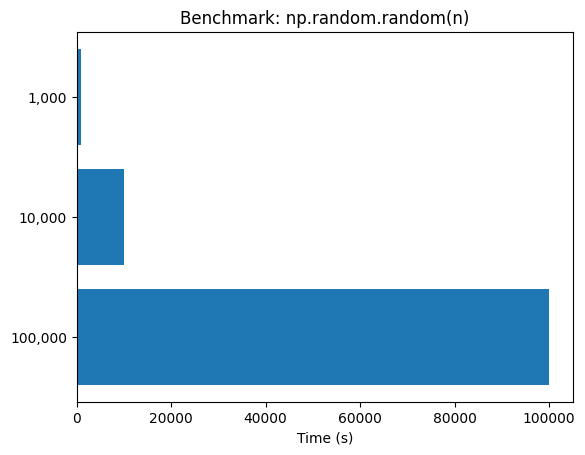

In [15]:
# Measurement 1: 1,000 Random Values
# MEASURE HERE
dur_1k = 1  # placeholder

# Measurment 2: 
# MEASURE HERE
dur_10k = 10 # placeholder

# Measurment 3
# MEASURE HERE
dur_100k = 100 # placeholder

plt.barh(['1,000', '10,000', '100,000'], [dur_1k * 1000, dur_10k * 1000, dur_100k * 1000])
plt.xlabel('Time (s)')
plt.title('Benchmark: np.random.random(n)');
plt.gca().invert_yaxis();

---

## Section 2: Performance is Stochastic

What we should have seen is that, when we run the same timing experiment repeatedly, we do not get the same result each time. This variance is **noise**, which can come from:
  1. **System load**: Memory is full, all the CPUs are busy, etc.  
  2. **CPU scheduling**: It takes time to get both the command and its data to the CPU, and 
  3. **Caching behavior**: Modern computing architectures have so many differnet systems to try and anticipate what data *might* be needed, and what code *might* be asked of it.  Sometimes it helps, sometimes not.
  4. **background processes**: Other your code needs to wait its turn among all the other code running on the computer.
  5. **temperature**: Yes, even the temperature of the computer.  
  
   
The key idea is that performance should be treated as a distribution, not a single value. Averages, standard deviation, and percentiles provide a more honest summary than a single measurement. Understanding variability is just as important as understanding central tendency.

In this notebook, we'll use the `%timeit` Jupyter notebook command to time code **repeatedly** and help us get the data needed for a better estimate of the code's performance.  Of note is that timeit has 

| Code | Description |
| :-- | :-- | 
| **`%timeit code()`** | Runs the `code()` many times and prints the average duration. |
| **`%timeit -r 10 code()`** | Runs the `code()` in 10 batches and prints the average duration of those 10 batches. |
| **`%timeit -n 20  code()`** | Runs the `code()` in batches of 20 loops and prints. |
| **`bench = %timeit -o code()`** | Runs the `code()` and returns the results to the `bench` variable. |
| **`bench.timings`** | a list of durations (one for each repeat) |
| --- | --- |
| **`np.mean(bench.timings)`** | the mean duration:  what **typically** happened. |
| **`np.std(bench.timings)`** | the standard deviation of the durations. |
| **`np.min(bench.timings)`** | the minimum duration: the **best-case, noise-free** run.|
| **`np.max(bench.timings)`** | the maximum duration: a really **noisy** run |



### Exercises

**Example**: Use `%timeit` to measure how long it takes to run `time.sleep(0.01)`:

In [16]:
%timeit time.sleep(0.01)

10.4 ms ± 6.61 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


**Exercise**: Use `%timeit` to measure how long it takes to run `np.random.random(10000)`

In [27]:
from timeit import Timer
from functools import partial

In [28]:
timer = Timer(partial(np.random.random, 10_000))
timer

In [30]:
timer.autorange()

(2000, 0.30139969999981986)

In [18]:
bench = %timeit -n 5 -r 100 -o  np.random.random(10_000)
np.mean(bench.timings)

124 μs ± 24.5 μs per loop (mean ± std. dev. of 100 runs, 5 loops each)


np.float64(0.00012402360000851332)

In [19]:
bench.average

0.0001240236000085133

In [22]:
bench.stdev

2.4454724767925874e-05

In [24]:
bench.worst, np.max(bench.timings)

(0.0002482600000803359, np.float64(0.0002482600000803359))

In [25]:
bench.best, np.min(bench.timings)

(0.00010485999991942663, np.float64(0.00010485999991942663))

**Exercise**: Use `%timeit -r 10` to do 10 repeated experiments, to measure how long it takes to run `np.random.random(10000)`

**Exercise**: Use `%timeit -r 10 -n 3` to do 10 repeated experiments of 3 calls each, to measure how long it takes to run `np.random.random(10000)`

**Example**: Extract the results from using `%timeit -r 5 -n 3` to do 5 repeated experiments of 5 calls each on `np.random.random(10000)`, and print the `.timings` attribue to view the data:

In [23]:
bench = %timeit -o -n 5 -r 5 np.random.random(10_000)
bench.timings

51.7 μs ± 2.92 μs per loop (mean ± std. dev. of 5 runs, 5 loops each)


[5.7340000057592985e-05,
 4.951999944751151e-05,
 4.961999948136508e-05,
 5.165999973542057e-05,
 5.041999975219369e-05]

**Exercise**: Extract the results from using `%timeit` to do 10 repeated experiments of 3 calls each on `np.random.random(10000)`, and print the `.timings` attribue to view the data:

**Exercise**: Verify `timeit`'s results: Run a benchmark experiment and calculate the average of the `timings` with `np.mean()`.  Are the values close?

**Exercise**: Verify `timeit`'s results: Run a benchmark experiment and calculate the standard deviation of the `timings` with `np.std()`.  Are the values close?

**Exercise**: Run a benchmark experiment with at least 100 repeats, and find: What was the best time measured (`np.min()`)?  What was the worst time measured (`np.max()`)?

---

## Section 3: Visualizing Distributions as Histograms

How should we interpret the variance of this data?  To better-understand it, we need to look at the distribution itself.  For viewing statistical variability, both `Event Plots` and `Histograms` are good data visualizations.

.



| Code | Description |
| :-- | :-- |
| **`bench = %timeit -o -r 100 code()`** | Run a benchmark expeperiment on `code()` with 100 repeats, and output the results to `bench` |
| --- | --- | 
| **`plt.eventplot(bench.timings)`** | Plot a raster plot of the timing measurments |
| --- | --- |
| **`plt.hist(bench.timings)`** |  Plot a histogram of the timing measurements |
| **`plt.hist(..., bins=25)`** | Make the histogram have 25 bins (bars) |
| **`plt.hist(..., density=True, histtype='step', label='data 1')`** | For comparing histograms: Standardize the bar heights, make the bars transparent, and label the data for a legend. |
| --- | --- | 
| **`plt.legend()`** | Add a legend to the plot, automatically finding the data with `label=` values |
| **`plt.gca().set_xscale('log')`** |  Make the x-axis a log scale (good for comparing values different on orders of magnitude) |
| **`plt.gca().set_yscale('log')`** |  Make the y-axis a log scale (good for comparing values different on orders of magnitude) |
| **`plt.loglog()`** | A shortcut: make both the x and y axes on log scales |


### Exercises

**Example**: Run a benchmark with 15 repeats and plot the data an event plot:

12.2 μs ± 5.33 μs per loop (mean ± std. dev. of 15 runs, 50 loops each)


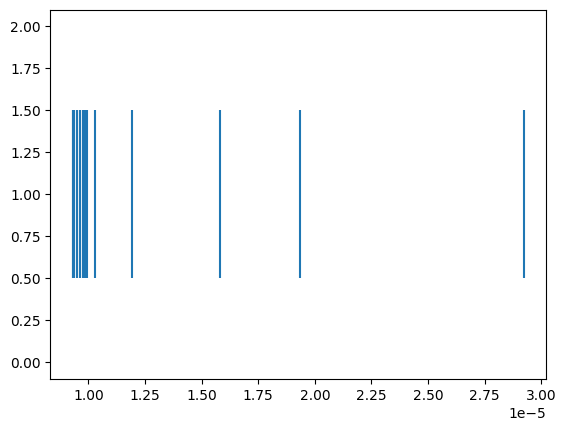

In [46]:
bench = %timeit -o -n 50 -r 15 np.random.random(1_000)
plt.eventplot(bench.timings);

**Exercise**: Run a benchmark with 100 repeats and plot the data an event plot:

**Exercise**: Run a benchmark with 1000 repeats and plot the data an event plot. 
  - This time, to reduce the effect of over-plotting, set `alpha` to something low, like 0.1

**Example**: Run a benchmark with 100 repeats and plot the data as a **histogram** (`plt.hist()`)

7.74 μs ± 782 ns per loop (mean ± std. dev. of 200 runs, 100 loops each)


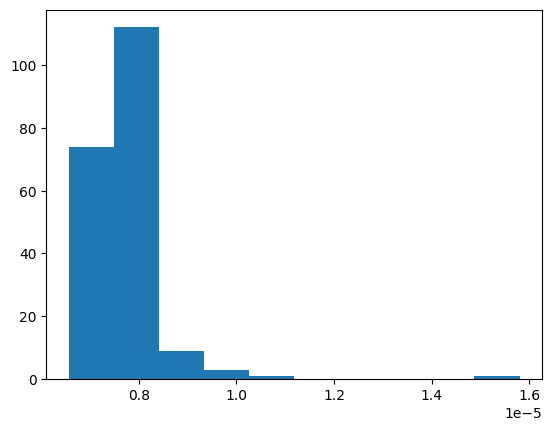

In [50]:
bench = %timeit -o -n 100 -r 200 np.random.random(1_000)
plt.hist(bench.timings);

**Exercise**: Run a benchmark with 1000 repeats and plot the data as a **histogram** (`plt.hist()`)

**Exercise**: Run a benchmark with 2000 repeats and plot the data as a **histogram** (`plt.hist()`), controlling the number of bins to get more detail about the distribution (eg. `plt.hist(..., bins=25)`)
  - How many bins strikes a good balance between detailed structure and noise for this experiment?

**Exercise**: Comparing Histograms

Let's do the benchmarking experiment again, comparing how much time it takes `np.random.random()` to:
  - generate 1,000 numbers,
  - generate 10,000 numbers,
  - generate 100,000 numbers,


Run benchmark experiments for all three and make a histogram that shows them all.  Some useful options:
  - `plt.hist(bench.timings, bins=35, density=True, histtype='step', label='Data Label')`
  - `plt.legend()`
  - `plt.loglog()`

The slowest run took 8.12 times longer than the fastest. This could mean that an intermediate result is being cached.
14.6 μs ± 5.65 μs per loop (mean ± std. dev. of 300 runs, 10 loops each)
183 μs ± 44.6 μs per loop (mean ± std. dev. of 300 runs, 10 loops each)
2.18 ms ± 337 μs per loop (mean ± std. dev. of 300 runs, 10 loops each)


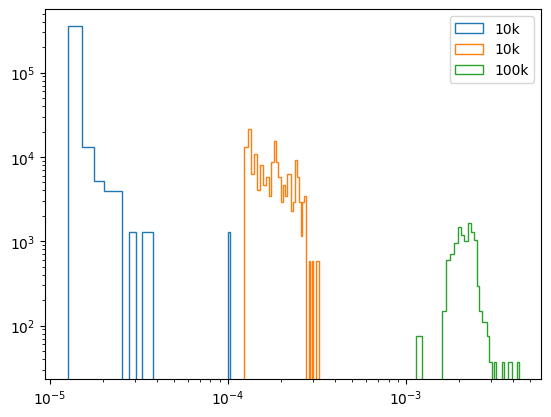

In [ ]:
bench_1k = %timeit -o -n 10 -r 300 np.random.random(1_000)
bench_10k = %timeit -o -n 10 -r 300 np.random.random(10_000)
bench_100k = %timeit -o -n 10 -r 300 np.random.random(100_000)

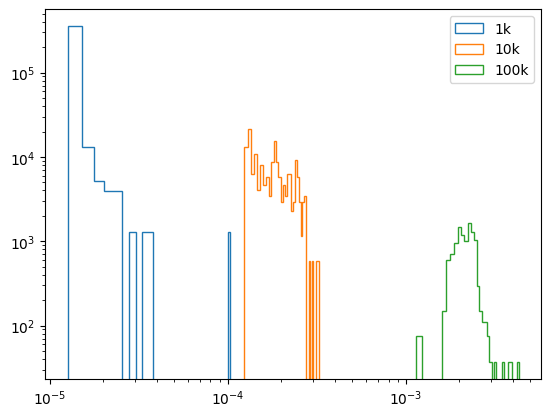

In [36]:


plt.hist(bench_1k.timings, bins=35, density=True, histtype='step', label='1k');
plt.hist(bench_10k.timings, bins=35, density=True, histtype='step', label='10k');
plt.hist(bench_100k.timings, bins=35, density=True, histtype='step', label='100k');
plt.legend();
# plt.loglog();
plt.gca().set_yscale('log')
plt.gca().set_xscale('log')

---

## Section 4: Measuring Time without Measuring the Clock.  (i.e. Why `timeit` has `-n` and `-r` parameters)

Finally, you reconstruct the logic behind timeit. By implementing repeated runs, averaging, standard deviation, best-case, and worst-case reporting — along with a progress bar — you move from using benchmarking tools to understanding them. This reinforces a critical mindset: tools are helpful, but you should know what assumptions they make and what statistics they report.

The broader lesson is this: timing results are data. And like all data, they require careful experimental design, replication, and statistical interpretation before drawing conclusions.

### Code Structure: "for" loops

The exercises below use the following two coding patterns:

1. Run a block of code 100 times:

```python
for _ in range(100):
    run_code()
```

2. Fill a list with 100 values:
```python
results = []
for _ in range(100):
    result = run_code()
    results.append(result)
```

### Exercises

**Exercise**: How long does it take to measure the time, **without doing any calculations in between two time measurements**? 

Use `for _ in range(1000):` to make a list of 1000 time duration measurements, and find:
  1. What is the average time?
  2. What is the "best" time (the minimium time, `np.min()`)?
  3. What is the "worst" time (the maximum time, `np.max()`)?
  4. Make a histogram with 100 bins (`plt.hist(timings, bins=100)`).  Are the times randomly varying between the minimum and maximum values?

**Exercise**

Let's make  our own `timeit`-like statistical benchmarking tool, using `time.perf_counter()`.  This will help us better-understand what `timeit` is doing behind the scenes for us. 

**Task**: Add the following features to the `benchmark()` function:
  1. Using `for _ in range(r):`, have `benchmark(r=10)` do 10 measurements.
  2. Using `for _ in range(n):`, have `benchmark(n=5)` run the function 5 times before measuring the elapsed time. (Note: `timing` should represent the average time per function run)
  3. Include the `"average"` time to the function's output (`np.mean()`):
  4. Include the `"std"` variance of the times to the function's output (`np.std()`):
  5. Include the `"best"` time to the function's output (`np.min()`)
  6. Include the `"worst"` time to the function's output (`np.max()`)
  7. Add a progress bar feature using the `tqdm()` function: `for _ in tqdm(range(r))`.
  


In [87]:
def benchmark(r, n, function, *args, **kwargs):
    """
    """
    timings = []

    t0 = time.perf_counter()
    function(*args, **kwargs)
    t1 = time.perf_counter()
    timing = t1 - t0
    timings.append(timing)

    return {
        'timings': timings
    }


benchmark(1, 1, np.random.random, 1_000)

{'timings': [0.0001188000023830682]}